# Statistics for Machine Learning

## Module 3 Overview Notebook

This notebook integrates all key concepts from Module 3:
1. Descriptive Statistics
2. Data Distribution
3. Probability Fundamentals
4. Statistical Distributions
5. Relationships
6. Exploratory Data Analysis
7. Dimensionality Reduction (PCA)
8. Clustering (K-Means)
9. Model Evaluation
10. Data Storytelling

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis, pearsonr, spearmanr
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.datasets import load_diabetes, load_wine

plt.style.use('ggplot')
%matplotlib inline

## 1. Descriptive Statistics

Computing mean, median, variance, std, and IQR.

In [2]:
data = np.random.normal(50, 10, 1000)
print(f"Mean: {np.mean(data):.2f}")
print(f"Median: {np.median(data):.2f}")
print(f"Std: {np.std(data, ddof=0):.2f}")
print(f"IQR: {np.percentile(data, 75) - np.percentile(data, 25):.2f}")

Mean: 50.01
Median: 49.97
Std: 9.80
IQR: 12.99


## 2. Data Distribution

Visualizing a distribution with histogram + KDE.

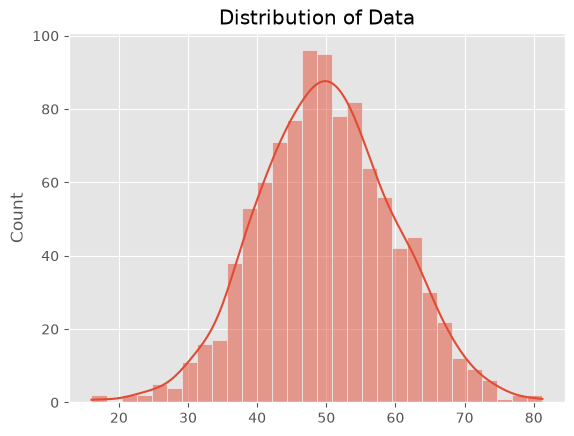

Skewness: 0.021, Kurtosis: 0.079


In [3]:
sns.histplot(data, bins=30, kde=True)
plt.title('Distribution of Data')
plt.show()
print(f"Skewness: {skew(data):.3f}, Kurtosis: {kurtosis(data):.3f}")

## 3. Probability

Bayes theorem: medical diagnostic test.

In [4]:
prevalence = 0.01
sensitivity = 0.95
specificity = 0.90
posterior = (sensitivity * prevalence) / (
    sensitivity * prevalence + (1 - specificity) * (1 - prevalence)
)
print(f"P(disease|positive) = {posterior:.3f}")

P(disease|positive) = 0.088


## 4. Statistical Distributions

Working with named distributions using scipy.stats.

In [5]:
print(f"Binomial P(X=3), n=10, p=0.3: {stats.binom(10, 0.3).pmf(3):.3f}")
print(f"Poisson P(X=2), lambda=3: {stats.poisson(3).pmf(2):.3f}")
print(f"Normal P(X<60), mu=50, sigma=10: {stats.norm(50, 10).cdf(60):.3f}")

Binomial P(X=3), n=10, p=0.3: 0.267
Poisson P(X=2), lambda=3: 0.224
Normal P(X<60), mu=50, sigma=10: 0.841


## 5. Relationships

Correlation analysis on penguins dataset.

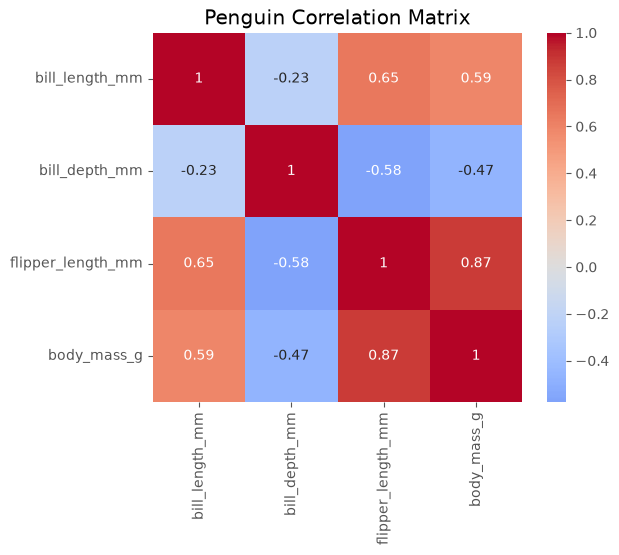

In [6]:
penguins = sns.load_dataset('penguins').dropna()
corr = penguins.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, square=True)
plt.title('Penguin Correlation Matrix')
plt.show()

## 6. EDA

Quick EDA on iris dataset.

In [7]:
iris = sns.load_dataset('iris')
print(iris.info())
print(iris.describe())

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB
None
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000


## 7. PCA

Dimensionality reduction on iris.

Explained variance: 0.958


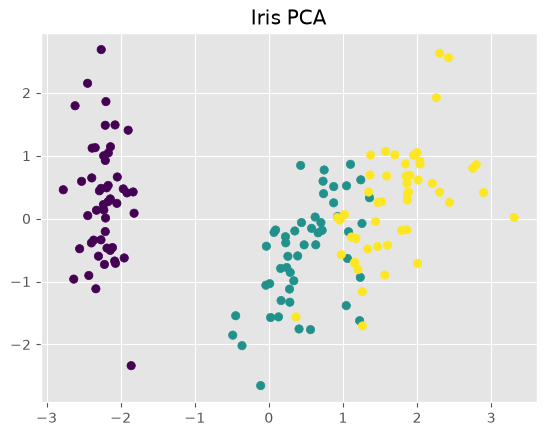

In [8]:
X = StandardScaler().fit_transform(iris.drop('species', axis=1))
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
print(f"Explained variance: {pca.explained_variance_ratio_.sum():.3f}")
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=iris['species'].astype('category').cat.codes, cmap='viridis')
plt.title('Iris PCA')
plt.show()

## 8. Clustering

K-Means on iris.

In [9]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)
print(pd.crosstab(iris['species'], clusters))

col_0        0   1   2
species               
setosa       0  50   0
versicolor  39   0  11
virginica   14   0  36


## 9. Model Evaluation

Train/Test split + metrics on diabetes dataset.

In [10]:
diabetes = load_diabetes()
X_train, X_test, y_train, y_test = train_test_split(
    diabetes.data, diabetes.target, test_size=0.2, random_state=42
)
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"R²: {r2_score(y_test, y_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

R²: 0.453
RMSE: 53.85


## 10. Data Storytelling

Effective visualization: penguin size by species.

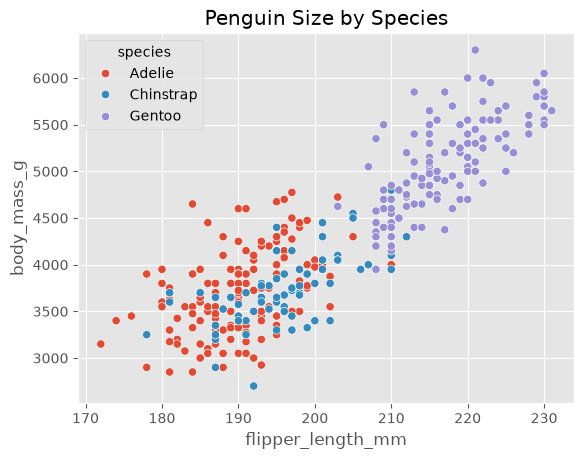

In [11]:
sns.scatterplot(data=penguins, x='flipper_length_mm', y='body_mass_g', hue='species')
plt.title('Penguin Size by Species')
plt.show()

---
This concludes the Module 3 overview. All concepts are covered in detail in the individual lesson notebooks.